In [1]:
# !pip install gensim
import numpy as np
import pandas as pd
import urllib.request
from gensim.utils import simple_preprocess
import os, re
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
# # Example custom dataset
AWA_custom_sentences = ['chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                    'persian cat', 'pig', 'raccoon', 'rat', 'seal']

SUN_custom_sentences = ["airport", "aquarium", "auditorium", "backyard", "bakery", "balcony", 
                        "bank", "basketball_court", "bathroom", "beach", "bookstore", "breakfast_table", 
                        "bridge", "bus_station", "cafeteria", "chapel", "church", "classroom", 
                        "cottage", "courtyard", "desert", "dock", "elevator", "farm", "fire_station", 
                        "fishpond", "flood", "forest", "garage", "greenhouse", "hill", "hospital", 
                        "house", "igloo", "jungle", "kitchen", "lawn", "living_room", "mansion", "mine", 
                        "mountain", "music_studio", "office_building", "outhouse", "park", "parking_lot", 
                        "phone_booth", "pizzeria", "podium", "pub", "railroad_track", "repair_shop", "river", 
                        "science_museum", "server_room", "shipping_room", "shower", "sky", "slum", "stage", 
                        "supermarket", "temple", "toll_plaza", "toyshop", "track", "train_railway", 
                        "trestle_bridge", "valley", "vinery", "voting_booth", "zoo"]

CUB_custom_sentences = ["Elegant_Tern", "Forsters_Tern", "Gray_Catbird", "Gray_Kingbird", "Green_Jay", 
                        "Ivory_Gull", "Laysan_Albatross", "Le_Conte_Sparrow", "Lincoln_Sparrow", 
                        "Louisiana_Waterthrush", "Marsh_Wren", "Mourning_Warbler", 
                        "Nelson_Sharp_tailed_Sparrow", "Orange_crowned_Warbler", "Orchard_Oriole", 
                        "Palm_Warbler", "Parakeet_Auklet", "Pied_billed_Grebe", "Pied_Kingfisher", 
                        "Pine_Grosbeak", "Pine_Warbler", "Red_eyed_Vireo", "Red_faced_Cormorant", 
                        "Red_headed_Woodpecker", "Rhinoceros_Auklet", "Rock_Wren", "Rose_breasted_Grosbeak", 
                        "Rufous_Hummingbird", "Rusty_Blackbird", "Savannah_Sparrow", "Scott_Oriole", 
                        "Seaside_Sparrow", "Song_Sparrow", "Summer_Tanager", "Tennessee_Warbler", 
                        "Tree_Sparrow", "Tree_Swallow", "Vermilion_Flycatcher", "Vesper_Sparrow", 
                        "Western_Gull", "White_breasted_Kingfisher", "White_breasted_Nuthatch", 
                        "White_crowned_Sparrow", "White_eyed_Vireo", "White_throated_Sparrow", 
                        "Worm_eating_Warbler", "Yellow_bellied_Flycatcher", "Yellow_billed_Cuckoo", 
                        "Yellow_headed_Blackbird", "Yellow_Warbler"]


In [3]:
# Load GloVe embeddings
def load_glove_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")  # Using 50d GloVe embeddings
# print(f"embeddings_index : {type(embeddings_index)} \n")

# Convert sentences to embeddings
def sentence_to_embedding(sentence, embeddings_index):
    words = simple_preprocess(sentence)
    valid_words = [embeddings_index[word] for word in words if word in embeddings_index]
    if valid_words:
        return np.mean(valid_words, axis=0)
    else:
        return np.zeros(300) # Using 50d GloVe embeddings
    
# custom_sentences = AWA_custom_sentences

# sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

In [ ]:

# AWA_custom_sentences = ['chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
#                     'persian cat', 'pig', 'raccoon', 'rat', 'seal']

# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")  # Using 50d GloVe embeddings
# print(f"embeddings_index : {type(embeddings_index)} \n")

# custom_sentences = AWA_custom_sentences

# sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

# df = pd.DataFrame(sentence_embeddings)
# # df.head()

# # len(custom_sentences), df.shape
# df['custom_sentences'] = custom_sentences
# df.head()

# X = df.drop(columns='custom_sentences')
# y = df['custom_sentences']

# # Apply PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # Create a DataFrame with PCA results and labels
# df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# df_pca['label'] = y

# # Plot with Seaborn
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label', palette='Set1', s=80)
# plt.title('AWA2 PCA Visualization')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')
# # plt.grid(True)
# # plt.legend()
# plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()

# # Save image with 400 DPI
# # plt.savefig("awa2_pca_plot.png", dpi=400, bbox_inches='tight')

# plt.show()

# AWA

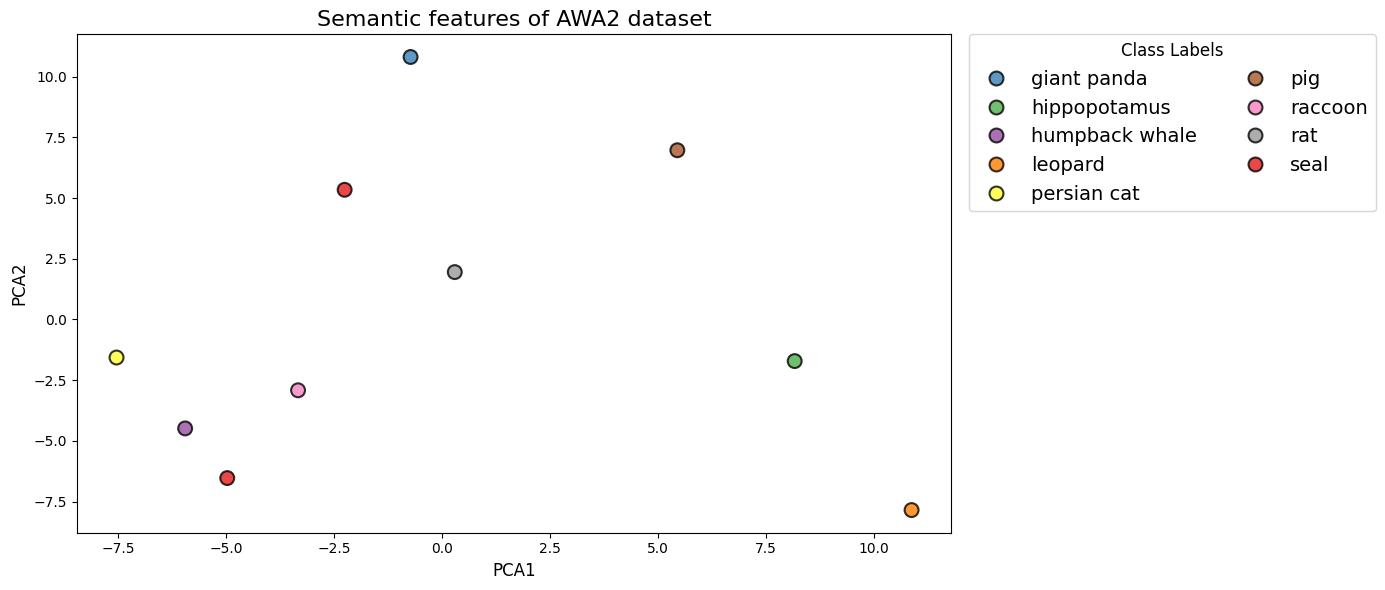

In [24]:
AWA_custom_sentences = ['chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                    'persian cat', 'pig', 'raccoon', 'rat', 'seal']

# Assuming you have these functions defined
# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(sentence, embeddings_index)

embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")  # Using 50d GloVe embeddings
# print(f"embeddings_index : {type(embeddings_index)} \n")


custom_sentences = AWA_custom_sentences

# Your embeddings code here (commented out for example)
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) 
                                for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

# print(f"embeddings_index : {type(embeddings_index)} \n")
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using edgecolor parameter ==========
plt.figure(figsize=(14, 6))

# Create scatter plot with circle outlines
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    palette='Set1', 
    s=100,  # Increased size for better visibility
    edgecolor='black',  # Black outline
    linewidth=1.5,  # Thickness of outline
    alpha=0.8  # Slight transparency
)

plt.title('Semantic features of AWA2 dataset', fontsize=16 ) # , fontweight='bold'
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, 
    fontsize=14, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("awa2_pca_plot.png", dpi=500, bbox_inches='tight')

plt.show()

### Option 1: Using different marker styles for each label

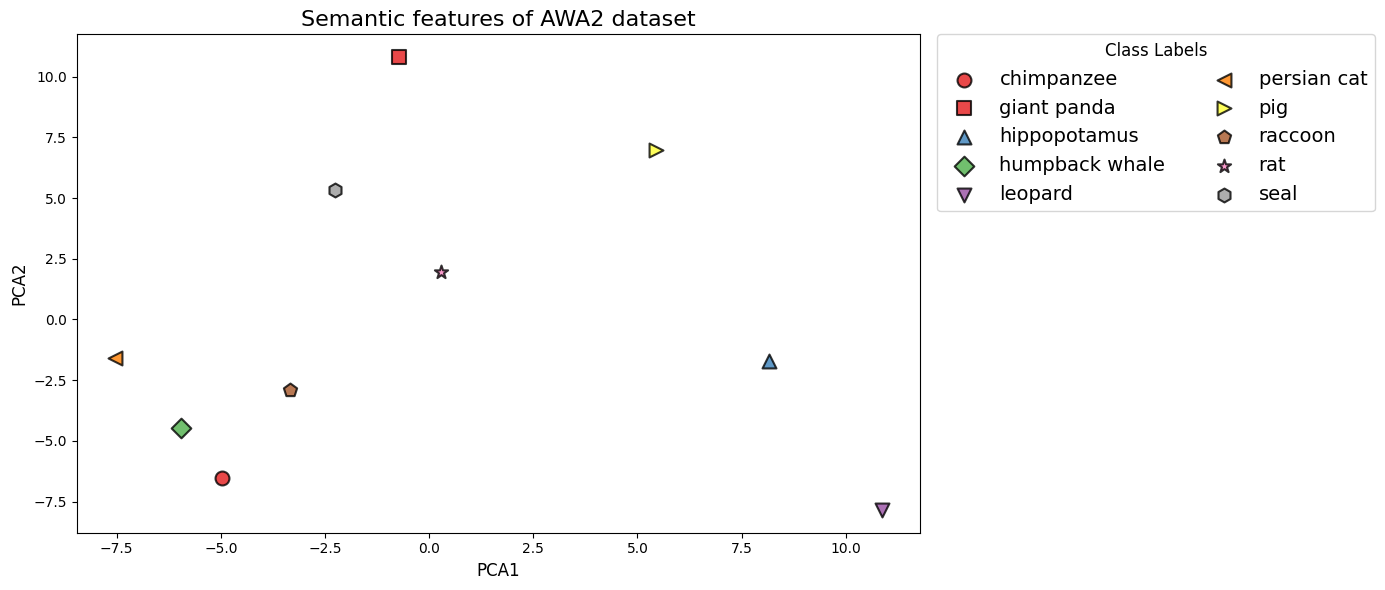

In [4]:
AWA_custom_sentences = ['chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                    'persian cat', 'pig', 'raccoon', 'rat', 'seal']

embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")

custom_sentences = AWA_custom_sentences

# Your embeddings code here (commented out for example)
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) 
                                for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using different marker styles ==========
plt.figure(figsize=(14, 6))

# Define marker styles for each unique label
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
unique_labels = df_pca['label'].unique()

# Create a scatter plot for each label with different markers
for i, label in enumerate(unique_labels):
    subset = df_pca[df_pca['label'] == label]
    plt.scatter(
        subset['PC1'], 
        subset['PC2'], 
        label=label,
        marker=marker_styles[i % len(marker_styles)],  # Cycle through markers
        s=100,  # Size
        edgecolor='black',  # Outline
        linewidth=1.5,
        alpha=0.8,
        c=[plt.cm.Set1(i / len(unique_labels))]  # Use colormap for consistent colors
    )

plt.title('Semantic features of AWA2 dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
plt.legend(
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, 
    fontsize=14, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("awa2_pca_plot_symbols.png", dpi=500, bbox_inches='tight')

plt.show()

### Option 2: Using seaborn with marker styles (more concise)

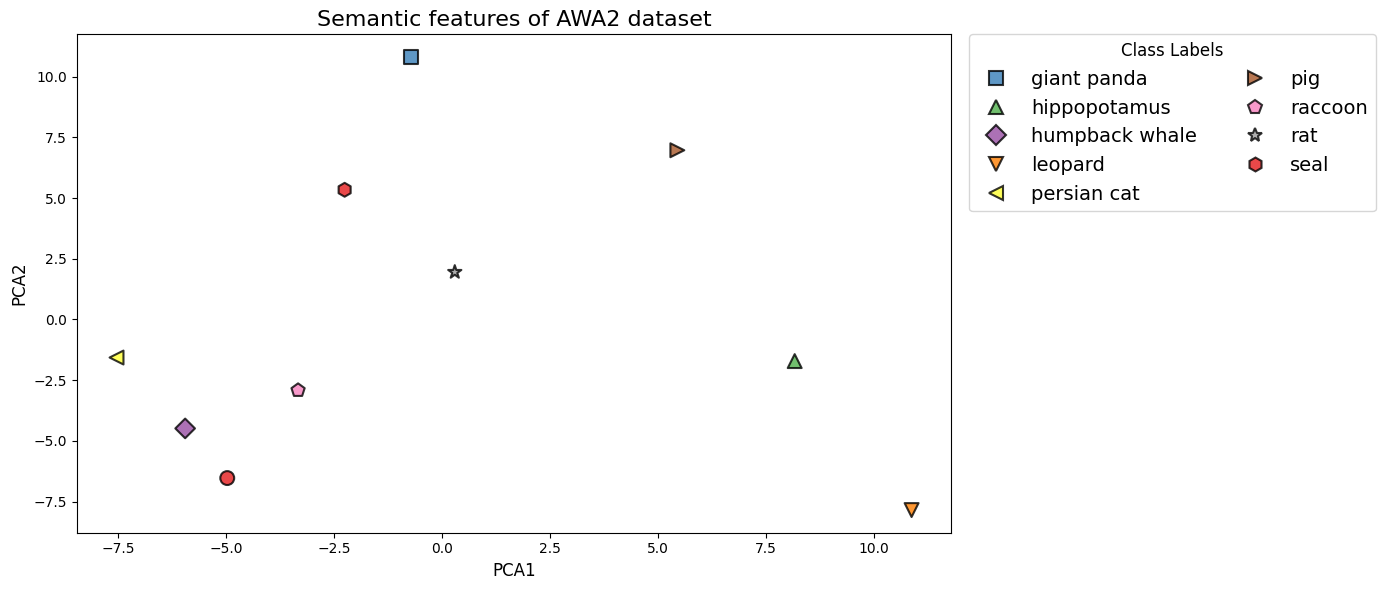

In [5]:
# ========== OPTION 2: Using seaborn with marker styles ==========
plt.figure(figsize=(14, 6))

# Define marker styles
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Create a mapping of labels to marker styles
label_to_marker = {label: marker_styles[i] for i, label in enumerate(df_pca['label'].unique())}

# Add marker column to dataframe
df_pca['marker'] = df_pca['label'].map(label_to_marker)

# Create scatter plot with different markers
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    style='label',  # Use 'label' column for marker styles
    markers=marker_styles[:len(df_pca['label'].unique())],  # Assign marker styles
    palette='Set1', 
    s=100,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8
)

plt.title('Semantic features of AWA2 dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, 
    fontsize=14, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("awa2_pca_plot_symbols_seaborn.png", dpi=500, bbox_inches='tight')

plt.show()

# SUN

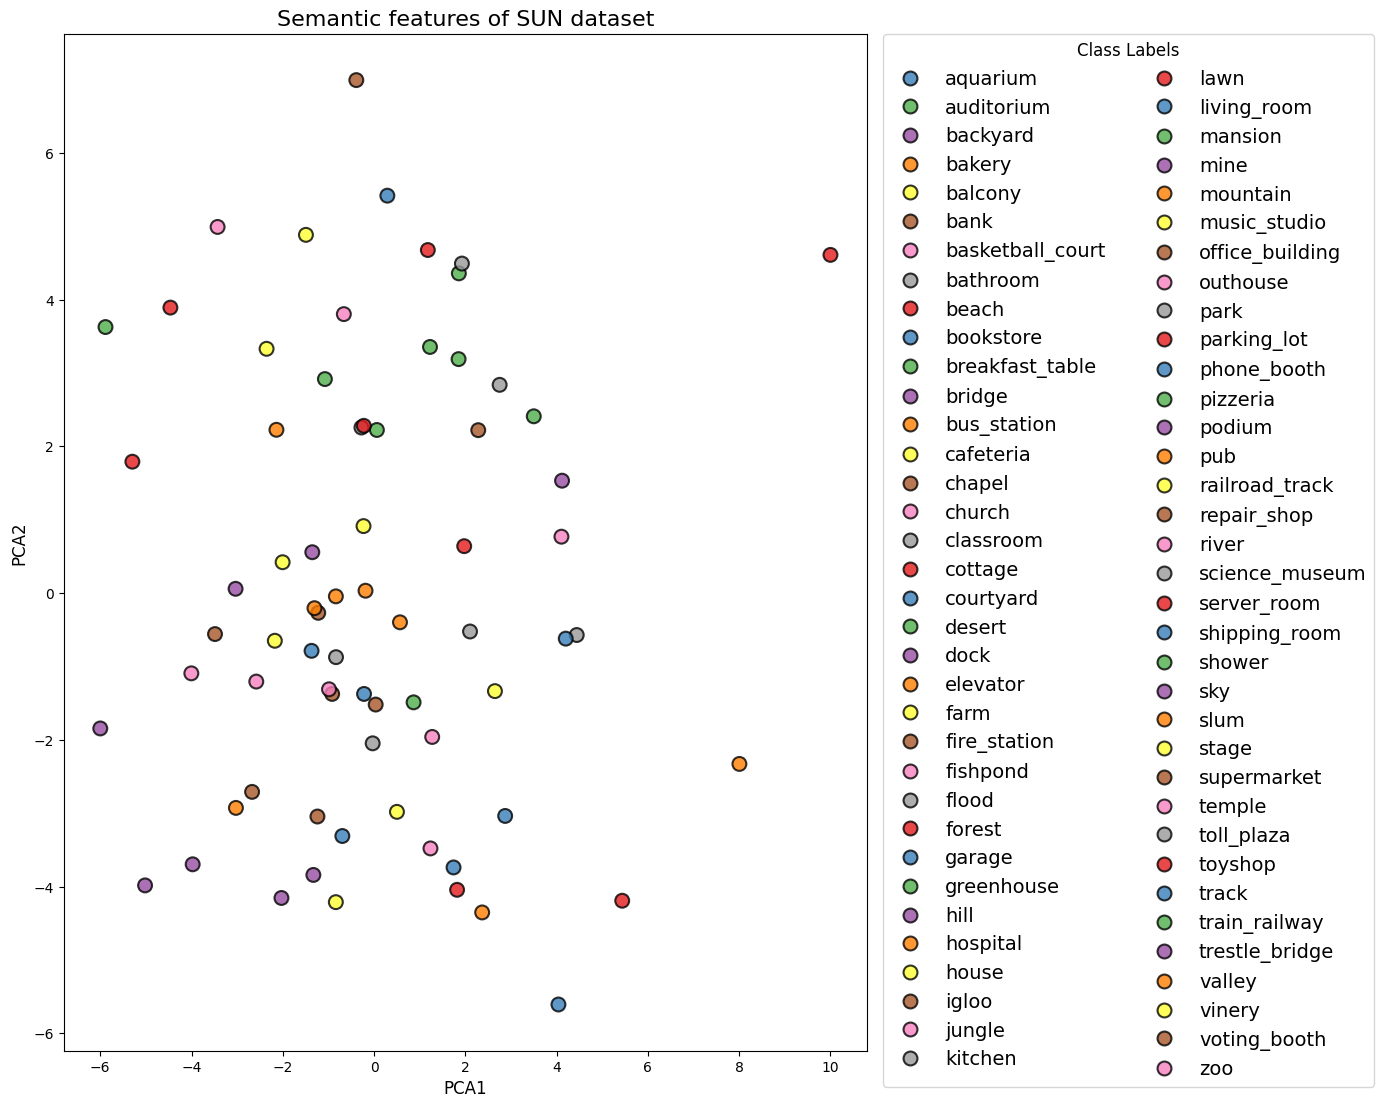

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
SUN_custom_sentences = ["airport", "aquarium", "auditorium", "backyard", "bakery", "balcony", 
                        "bank", "basketball_court", "bathroom", "beach", "bookstore", "breakfast_table", 
                        "bridge", "bus_station", "cafeteria", "chapel", "church", "classroom", 
                        "cottage", "courtyard", "desert", "dock", "elevator", "farm", "fire_station", 
                        "fishpond", "flood", "forest", "garage", "greenhouse", "hill", "hospital", 
                        "house", "igloo", "jungle", "kitchen", "lawn", "living_room", "mansion", "mine", 
                        "mountain", "music_studio", "office_building", "outhouse", "park", "parking_lot", 
                        "phone_booth", "pizzeria", "podium", "pub", "railroad_track", "repair_shop", "river", 
                        "science_museum", "server_room", "shipping_room", "shower", "sky", "slum", "stage", 
                        "supermarket", "temple", "toll_plaza", "toyshop", "track", "train_railway", 
                        "trestle_bridge", "valley", "vinery", "voting_booth", "zoo"]

# Assuming you have these functions defined
embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(SUN_custom_sentences, embeddings_index)

custom_sentences = SUN_custom_sentences

# Your embeddings code here (commented out for example)
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

# print(f"embeddings_index : {type(embeddings_index)} \n")
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using edgecolor parameter ==========
plt.figure(figsize=(14, 12))

# Create scatter plot with circle outlines
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    palette='Set1', 
    s=100,  # Increased size for better visibility
    edgecolor='black',  # Black outline
    linewidth=1.5,  # Thickness of outline
    alpha=0.8  # Slight transparency
)

plt.title('Semantic features of SUN dataset', fontsize=16 ) # , fontweight='bold'
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, 
    fontsize=14, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("sun_pca_plot.png", dpi=500, bbox_inches='tight')

plt.show()

### Option 1: Using different marker styles with matplotlib

C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\1440415997.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\1440415997.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\1440415997.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\1440415997.py:58: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('_').  Matplotlib is ignoring the e

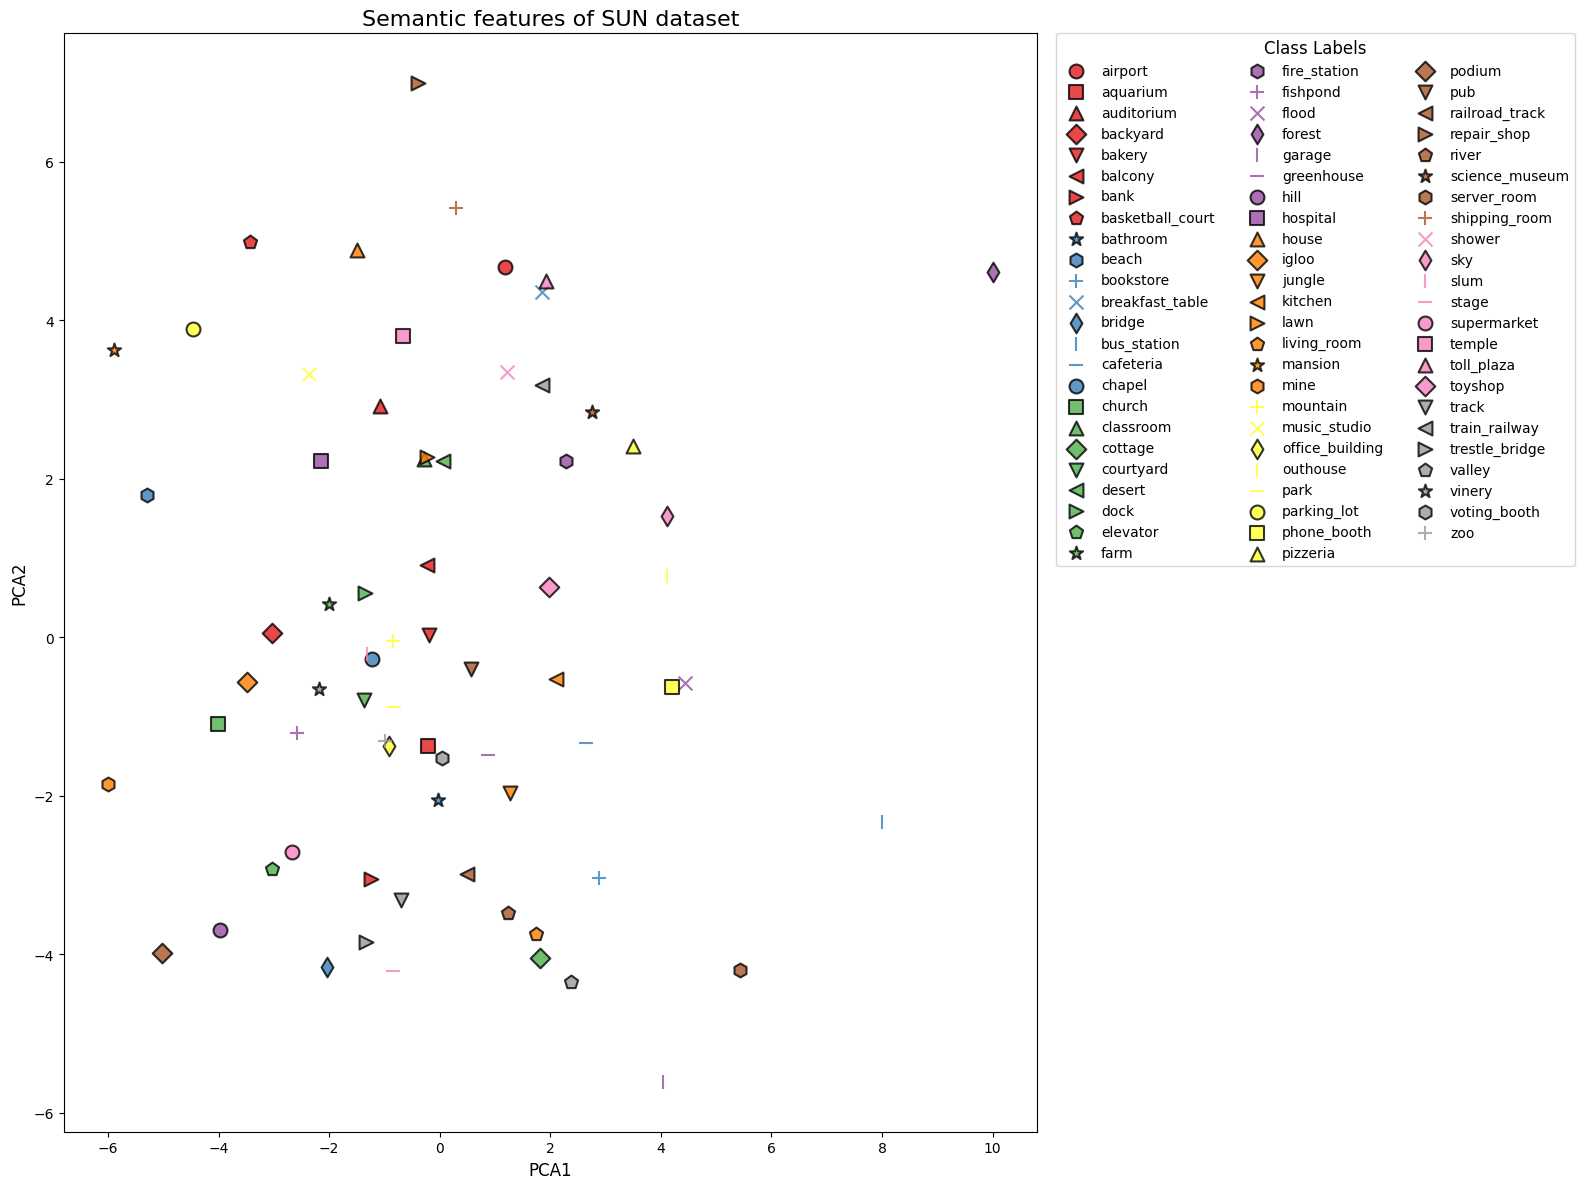

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
SUN_custom_sentences = ["airport", "aquarium", "auditorium", "backyard", "bakery", "balcony", 
                        "bank", "basketball_court", "bathroom", "beach", "bookstore", "breakfast_table", 
                        "bridge", "bus_station", "cafeteria", "chapel", "church", "classroom", 
                        "cottage", "courtyard", "desert", "dock", "elevator", "farm", "fire_station", 
                        "fishpond", "flood", "forest", "garage", "greenhouse", "hill", "hospital", 
                        "house", "igloo", "jungle", "kitchen", "lawn", "living_room", "mansion", "mine", 
                        "mountain", "music_studio", "office_building", "outhouse", "park", "parking_lot", 
                        "phone_booth", "pizzeria", "podium", "pub", "railroad_track", "repair_shop", "river", 
                        "science_museum", "server_room", "shipping_room", "shower", "sky", "slum", "stage", 
                        "supermarket", "temple", "toll_plaza", "toyshop", "track", "train_railway", 
                        "trestle_bridge", "valley", "vinery", "voting_booth", "zoo"]

# Assuming you have these functions defined
embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(SUN_custom_sentences, embeddings_index)

custom_sentences = SUN_custom_sentences

# Your embeddings code here (commented out for example)
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using matplotlib with marker styles ==========
plt.figure(figsize=(16, 12))

# Define marker styles (cycling through available markers)
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '+', 'x', 'd', '|', '_']
unique_labels = df_pca['label'].unique()

# Create a scatter plot for each label with different markers
for i, label in enumerate(unique_labels):
    subset = df_pca[df_pca['label'] == label]
    plt.scatter(
        subset['PC1'], 
        subset['PC2'], 
        label=label,
        marker=marker_styles[i % len(marker_styles)],  # Cycle through markers
        s=100,  # Size
        edgecolor='black',  # Outline
        linewidth=1.5,
        alpha=0.8,
        c=[plt.cm.Set1(i / len(unique_labels))]  # Use colormap for consistent colors
    )

plt.title('Semantic features of SUN dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend (adjust ncol based on number of labels)
ncol = 3 if len(unique_labels) > 20 else 2
plt.legend(
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=ncol, 
    fontsize=10, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("sun_pca_plot_symbols.png", dpi=500, bbox_inches='tight')

plt.show()

### Option 2: Using seaborn with marker styles (more concise for large datasets)

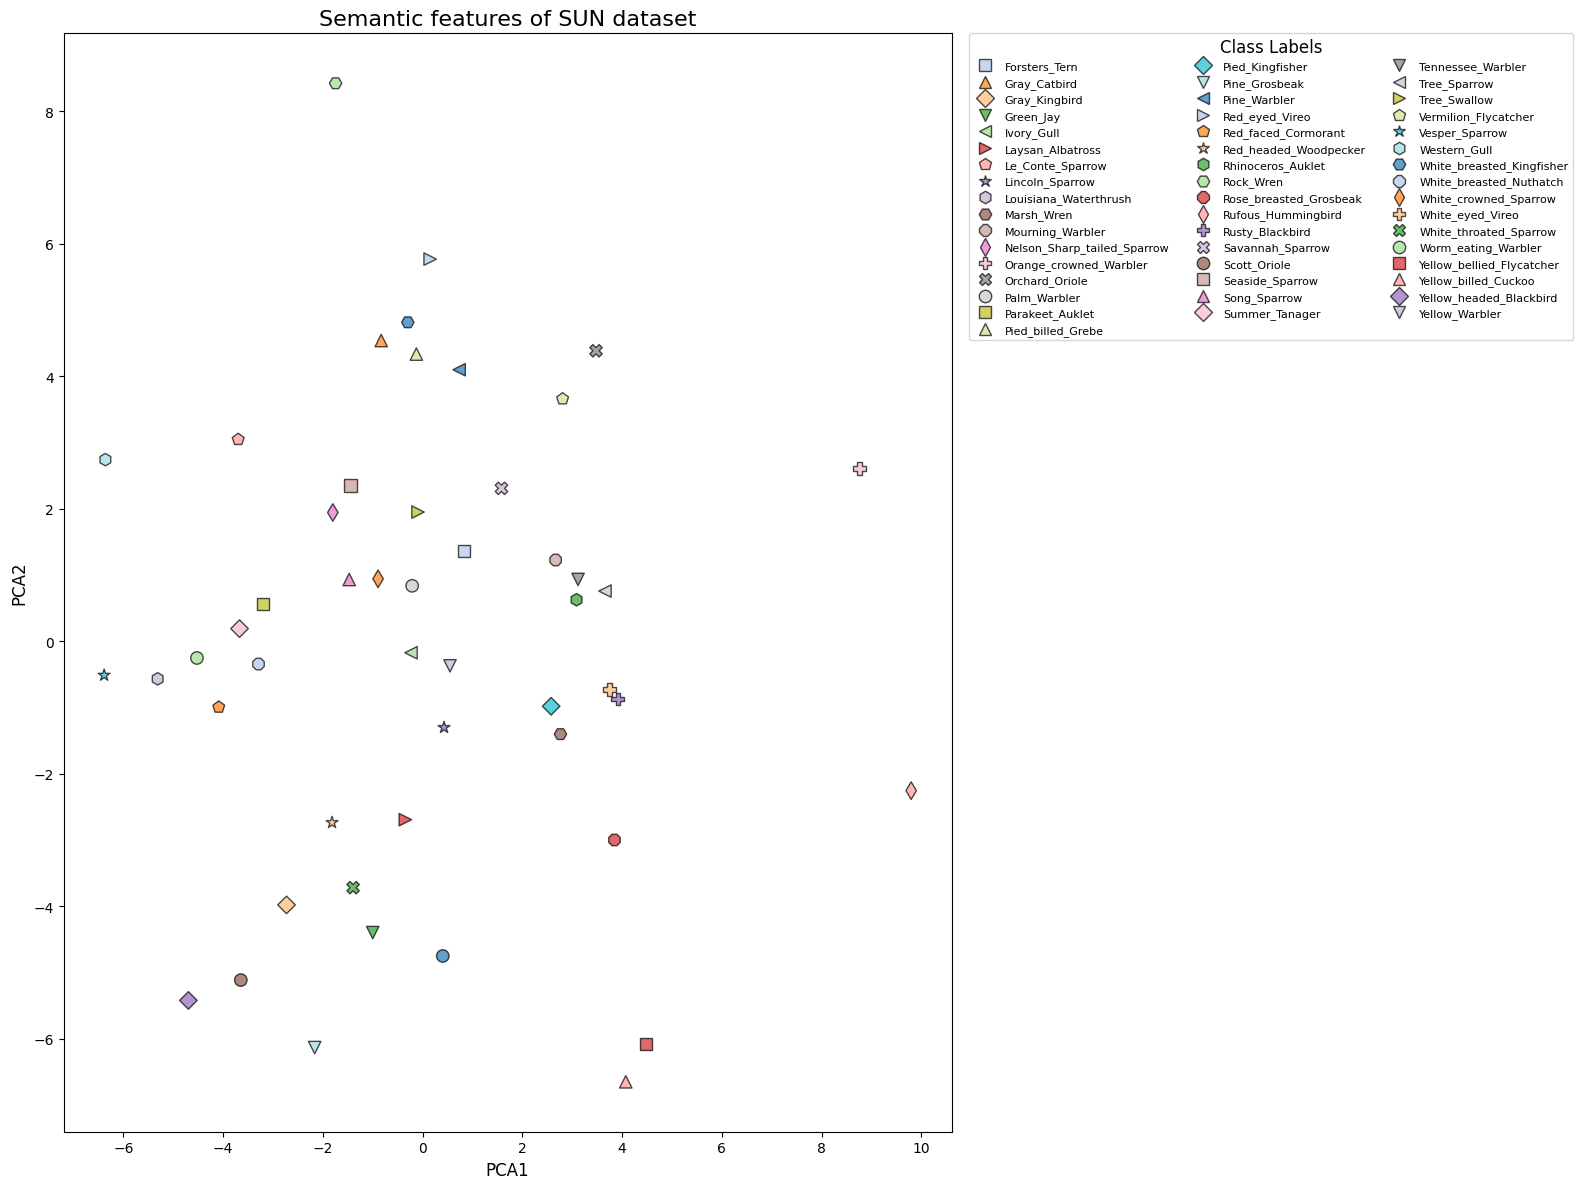

In [12]:
# ========== OPTION 2: Using seaborn with ONLY FILLED markers ==========
plt.figure(figsize=(16, 12))

# Define ONLY FILLED marker styles (no line art markers like '+', 'x', '|', '_')
filled_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '8', 'd', 'P', 'X']
# Common filled markers available in matplotlib:
# 'o' - circle
# 's' - square
# '^' - triangle up
# 'v' - triangle down
# '<' - triangle left
# '>' - triangle right
# 'D' - diamond
# 'd' - thin diamond
# 'p' - pentagon
# '*' - star
# 'h' - hexagon1
# 'H' - hexagon2
# '8' - octagon
# 'P' - plus (filled)
# 'X' - X (filled)

# Extend markers to have enough for 70+ categories by repeating
filled_markers_extended = filled_markers * 5  # 15 * 5 = 75 markers

# Get unique labels
unique_labels = df_pca['label'].unique()

# Create marker dictionary (using only filled markers)
# Ensure we have exactly as many markers as unique labels
marker_dict = {label: filled_markers_extended[i] for i, label in enumerate(unique_labels)}

# Create scatter plot with different markers using seaborn
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    style='label',  # Use 'label' column for marker styles
    markers=marker_dict,  # Assign marker styles (all filled)
    palette='tab20',  # Using tab20 for more colors (will cycle)
    s=80,  # Slightly smaller size for better visibility with many points
    edgecolor='black',
    linewidth=1,
    alpha=0.7,
    legend='full'
)

plt.title('Semantic features of SUN dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Customize legend for better readability with many categories
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., 
    ncol=3,  # 3 columns for better space utilization
    fontsize=8,  # Smaller font for many labels
    title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("sun_pca_plot_symbols_seaborn.png", dpi=500, bbox_inches='tight')

plt.show()

# CUB

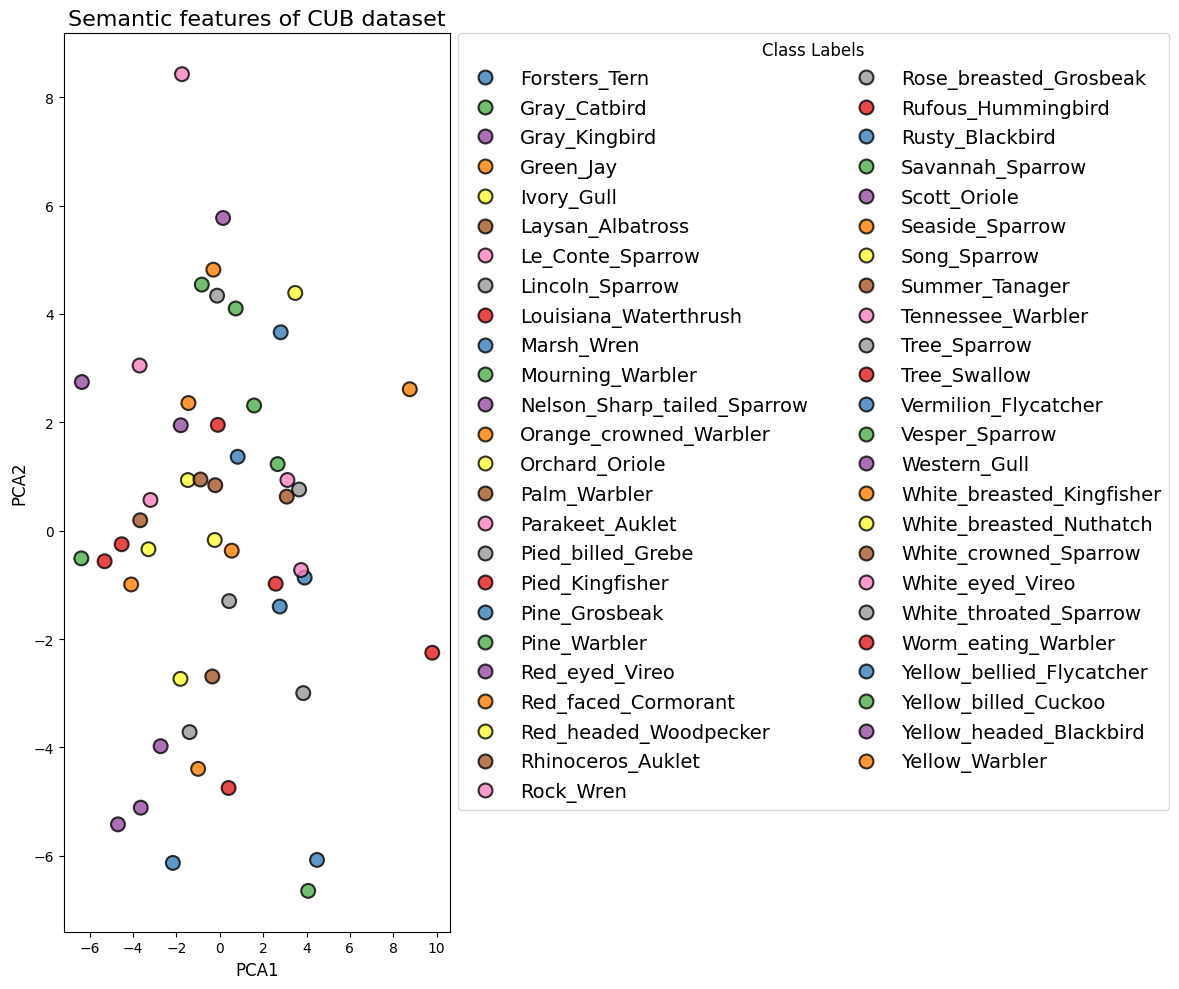

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
CUB_custom_sentences = ["Elegant_Tern", "Forsters_Tern", "Gray_Catbird", "Gray_Kingbird", "Green_Jay", 
                        "Ivory_Gull", "Laysan_Albatross", "Le_Conte_Sparrow", "Lincoln_Sparrow", 
                        "Louisiana_Waterthrush", "Marsh_Wren", "Mourning_Warbler", 
                        "Nelson_Sharp_tailed_Sparrow", "Orange_crowned_Warbler", "Orchard_Oriole", 
                        "Palm_Warbler", "Parakeet_Auklet", "Pied_billed_Grebe", "Pied_Kingfisher", 
                        "Pine_Grosbeak", "Pine_Warbler", "Red_eyed_Vireo", "Red_faced_Cormorant", 
                        "Red_headed_Woodpecker", "Rhinoceros_Auklet", "Rock_Wren", "Rose_breasted_Grosbeak", 
                        "Rufous_Hummingbird", "Rusty_Blackbird", "Savannah_Sparrow", "Scott_Oriole", 
                        "Seaside_Sparrow", "Song_Sparrow", "Summer_Tanager", "Tennessee_Warbler", 
                        "Tree_Sparrow", "Tree_Swallow", "Vermilion_Flycatcher", "Vesper_Sparrow", 
                        "Western_Gull", "White_breasted_Kingfisher", "White_breasted_Nuthatch", 
                        "White_crowned_Sparrow", "White_eyed_Vireo", "White_throated_Sparrow", 
                        "Worm_eating_Warbler", "Yellow_bellied_Flycatcher", "Yellow_billed_Cuckoo", 
                        "Yellow_headed_Blackbird", "Yellow_Warbler"]


# Assuming you have these functions defined
embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(SUN_custom_sentences, embeddings_index)

custom_sentences = CUB_custom_sentences

# Your embeddings code here (commented out for example)
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

# print(f"embeddings_index : {type(embeddings_index)} \n")
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# # ========== OPTION 1: Using edgecolor parameter ==========
# plt.figure(figsize=(12, 10))

# # Create scatter plot with circle outlines
# scatter = sns.scatterplot(
#     data=df_pca, 
#     x='PC1', 
#     y='PC2', 
#     hue='label', 
#     palette='Set1', 
#     s=100,  # Increased size for better visibility
#     edgecolor='black',  # Black outline
#     linewidth=1.5,  # Thickness of outline
#     alpha=0.8  # Slight transparency
# )

# plt.title('Semantic features of CUB dataset', fontsize=16 ) # , fontweight='bold'
# plt.xlabel('PCA1', fontsize=12)
# plt.ylabel('PCA2', fontsize=12)

# # Custom two-column legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, 
#     fontsize=14, title_fontsize=12
# )

# plt.tight_layout()

# # Save image with 500 DPI
# plt.savefig("cub_pca_plot.png", dpi=500, bbox_inches='tight')

# plt.show()

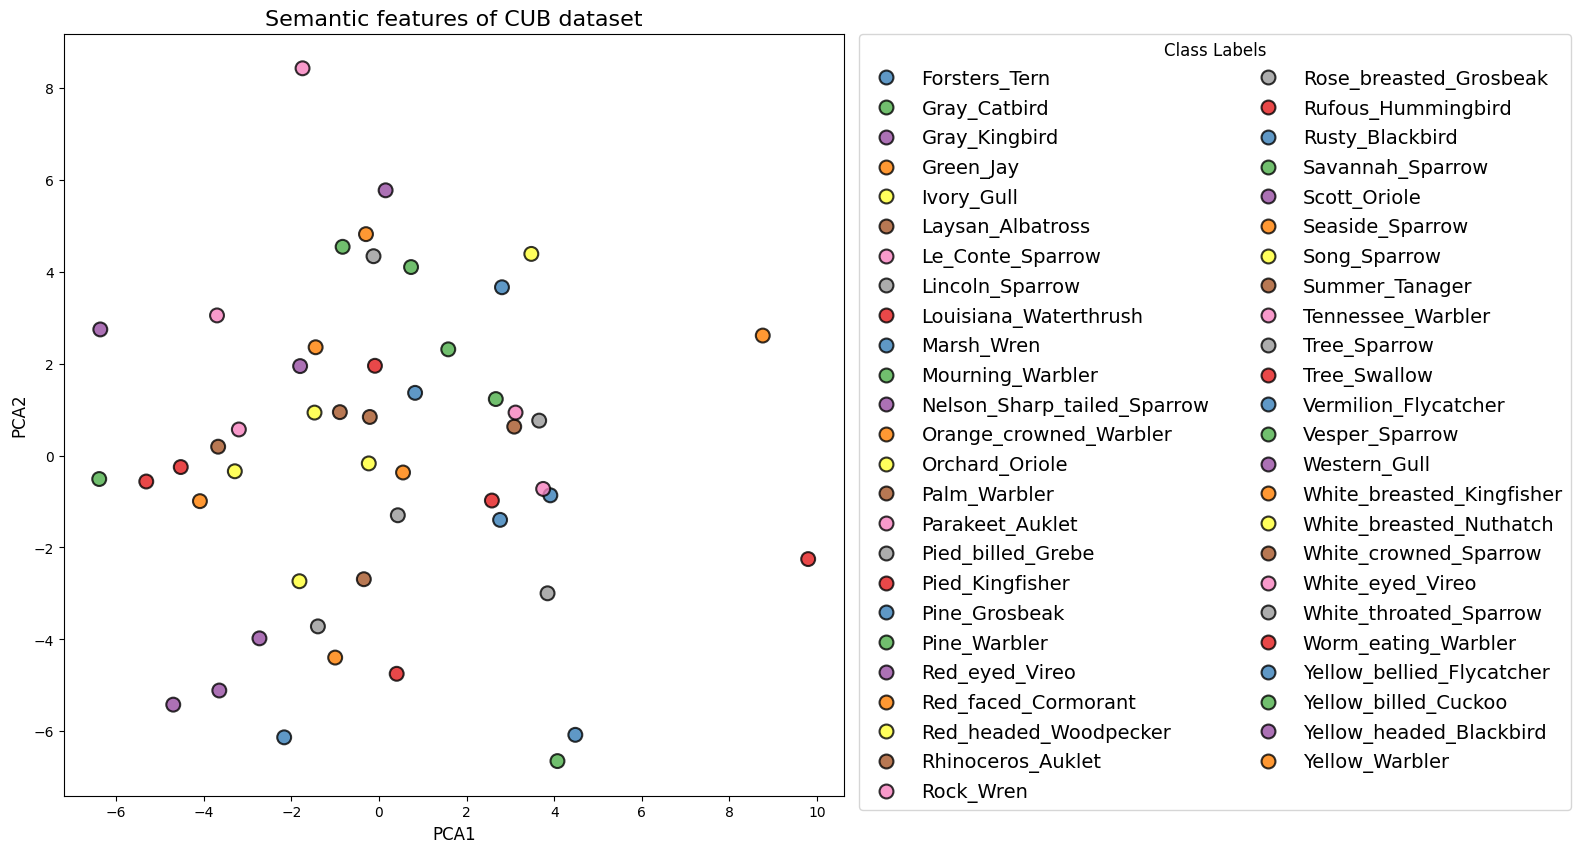

In [33]:
# ========== OPTION 1: Using edgecolor parameter ==========
plt.figure(figsize=(16, 9))

# Create scatter plot with circle outlines
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    palette='Set1', 
    s=100,  # Increased size for better visibility
    edgecolor='black',  # Black outline
    linewidth=1.5,  # Thickness of outline
    alpha=0.8  # Slight transparency
)

plt.title('Semantic features of CUB dataset', fontsize=16 ) # , fontweight='bold'
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, 
    fontsize=14, title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("cub_pca_plot.png", dpi=500, bbox_inches='tight')

plt.show()

C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\3041729457.py:64: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\3041729457.py:64: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\3041729457.py:64: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\Kiran\AppData\Local\Temp\ipykernel_60\3041729457.py:64: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('_').  Matplotlib is ignoring the e

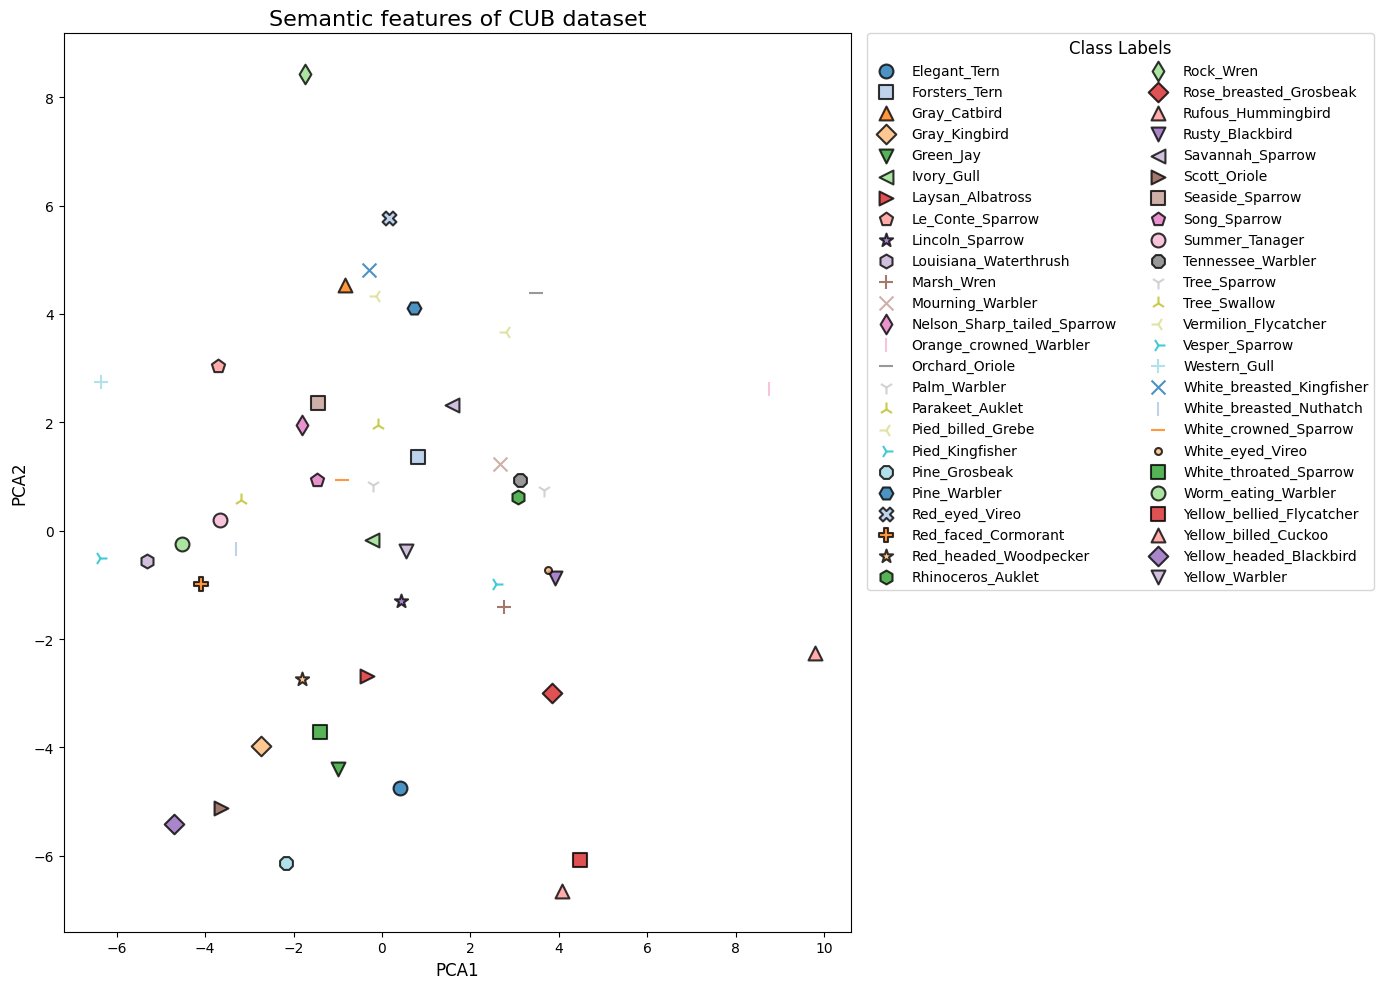

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
CUB_custom_sentences = ["Elegant_Tern", "Forsters_Tern", "Gray_Catbird", "Gray_Kingbird", "Green_Jay", 
                        "Ivory_Gull", "Laysan_Albatross", "Le_Conte_Sparrow", "Lincoln_Sparrow", 
                        "Louisiana_Waterthrush", "Marsh_Wren", "Mourning_Warbler", 
                        "Nelson_Sharp_tailed_Sparrow", "Orange_crowned_Warbler", "Orchard_Oriole", 
                        "Palm_Warbler", "Parakeet_Auklet", "Pied_billed_Grebe", "Pied_Kingfisher", 
                        "Pine_Grosbeak", "Pine_Warbler", "Red_eyed_Vireo", "Red_faced_Cormorant", 
                        "Red_headed_Woodpecker", "Rhinoceros_Auklet", "Rock_Wren", "Rose_breasted_Grosbeak", 
                        "Rufous_Hummingbird", "Rusty_Blackbird", "Savannah_Sparrow", "Scott_Oriole", 
                        "Seaside_Sparrow", "Song_Sparrow", "Summer_Tanager", "Tennessee_Warbler", 
                        "Tree_Sparrow", "Tree_Swallow", "Vermilion_Flycatcher", "Vesper_Sparrow", 
                        "Western_Gull", "White_breasted_Kingfisher", "White_breasted_Nuthatch", 
                        "White_crowned_Sparrow", "White_eyed_Vireo", "White_throated_Sparrow", 
                        "Worm_eating_Warbler", "Yellow_bellied_Flycatcher", "Yellow_billed_Cuckoo", 
                        "Yellow_headed_Blackbird", "Yellow_Warbler"]

# Assuming you have these functions defined
embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(CUB_custom_sentences, embeddings_index)

custom_sentences = CUB_custom_sentences

# Your embeddings code here
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using matplotlib with marker styles ==========
plt.figure(figsize=(14, 10))

# Define marker styles (enough markers for 50 categories)
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '+', 'x', 'd', '|', '_',
                 '1', '2', '3', '4', '8', 'H', 'X', 'P', '*', 'h', 'd', 'D', '^', 'v', '<',
                 '>', 's', 'p', 'o', '8', '1', '2', '3', '4', '+', 'x', '|', '_', '.', ',']

unique_labels = df_pca['label'].unique()

# Create a scatter plot for each label with different markers
for i, label in enumerate(unique_labels):
    subset = df_pca[df_pca['label'] == label]
    plt.scatter(
        subset['PC1'], 
        subset['PC2'], 
        label=label,
        marker=marker_styles[i % len(marker_styles)],  # Cycle through markers
        s=100,  # Size
        edgecolor='black',  # Outline
        linewidth=1.5,
        alpha=0.8,
        c=[plt.cm.tab20(i % 20)]  # Use colormap for consistent colors
    )

plt.title('Semantic features of CUB dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Custom two-column legend
plt.legend(
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., 
    ncol=2, 
    fontsize=10,  # Slightly smaller font for 50 labels
    title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("cub_pca_plot_symbols.png", dpi=500, bbox_inches='tight')

plt.show()

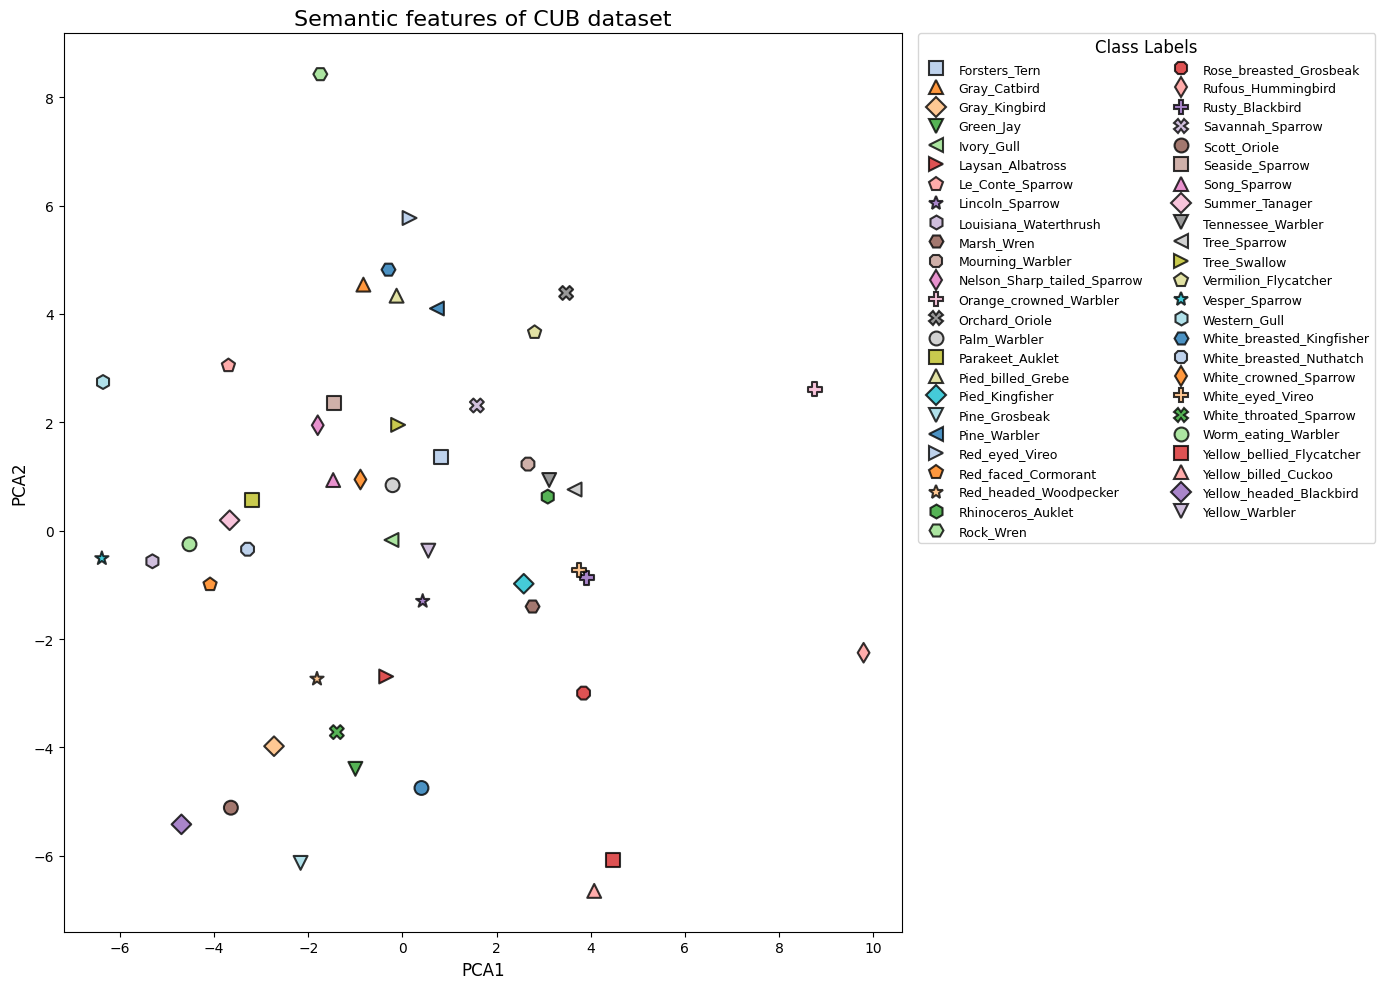

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
CUB_custom_sentences = ["Elegant_Tern", "Forsters_Tern", "Gray_Catbird", "Gray_Kingbird", "Green_Jay", 
                        "Ivory_Gull", "Laysan_Albatross", "Le_Conte_Sparrow", "Lincoln_Sparrow", 
                        "Louisiana_Waterthrush", "Marsh_Wren", "Mourning_Warbler", 
                        "Nelson_Sharp_tailed_Sparrow", "Orange_crowned_Warbler", "Orchard_Oriole", 
                        "Palm_Warbler", "Parakeet_Auklet", "Pied_billed_Grebe", "Pied_Kingfisher", 
                        "Pine_Grosbeak", "Pine_Warbler", "Red_eyed_Vireo", "Red_faced_Cormorant", 
                        "Red_headed_Woodpecker", "Rhinoceros_Auklet", "Rock_Wren", "Rose_breasted_Grosbeak", 
                        "Rufous_Hummingbird", "Rusty_Blackbird", "Savannah_Sparrow", "Scott_Oriole", 
                        "Seaside_Sparrow", "Song_Sparrow", "Summer_Tanager", "Tennessee_Warbler", 
                        "Tree_Sparrow", "Tree_Swallow", "Vermilion_Flycatcher", "Vesper_Sparrow", 
                        "Western_Gull", "White_breasted_Kingfisher", "White_breasted_Nuthatch", 
                        "White_crowned_Sparrow", "White_eyed_Vireo", "White_throated_Sparrow", 
                        "Worm_eating_Warbler", "Yellow_bellied_Flycatcher", "Yellow_billed_Cuckoo", 
                        "Yellow_headed_Blackbird", "Yellow_Warbler"]

# Assuming you have these functions defined
embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(CUB_custom_sentences, embeddings_index)

custom_sentences = CUB_custom_sentences

# Your embeddings code here
sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 2: Using seaborn with ONLY FILLED markers ==========
plt.figure(figsize=(14, 10))

# Define ONLY FILLED marker styles (no line art markers like '+', 'x', '|', '_')
filled_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '8', 'd', 'P', 'X']
# Adding more filled markers by repeating and slightly varying
filled_markers_extended = filled_markers * 4  # Repeat to have enough for 50 categories

# Get unique labels
unique_labels = df_pca['label'].unique()

# Create marker dictionary (using only filled markers)
marker_dict = {label: filled_markers_extended[i] for i, label in enumerate(unique_labels)}

# Create scatter plot with different markers using seaborn
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    style='label',  # Use 'label' column for marker styles
    markers=marker_dict,  # Assign marker styles (all filled)
    palette='tab20',  # Using tab20 for more colors (will cycle)
    s=100,  # Size
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8,
    legend='full'
)

plt.title('Semantic features of CUB dataset', fontsize=16)
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Customize legend for better readability with many categories
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., 
    ncol=2,  # 2 columns for 50 labels
    fontsize=9,  # Smaller font for many labels
    title_fontsize=12
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("cub_pca_plot_symbols_seaborn.png", dpi=500, bbox_inches='tight')

plt.show()

In [ ]:
# SUN_custom_sentences = ["airport", "aquarium", "auditorium", "backyard", "bakery", "balcony", 
#                         "bank", "basketball_court", "bathroom", "beach", "bookstore", "breakfast_table", 
#                         "bridge", "bus_station", "cafeteria", "chapel", "church", "classroom", 
#                         "cottage", "courtyard", "desert", "dock", "elevator", "farm", "fire_station", 
#                         "fishpond", "flood", "forest", "garage", "greenhouse", "hill", "hospital", 
#                         "house", "igloo", "jungle", "kitchen", "lawn", "living_room", "mansion", "mine", 
#                         "mountain", "music_studio", "office_building", "outhouse", "park", "parking_lot", 
#                         "phone_booth", "pizzeria", "podium", "pub", "railroad_track", "repair_shop", "river", 
#                         "science_museum", "server_room", "shipping_room", "shower", "sky", "slum", "stage", 
#                         "supermarket", "temple", "toll_plaza", "toyshop", "track", "train_railway", 
#                         "trestle_bridge", "valley", "vinery", "voting_booth", "zoo"]

# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")  # Using 300d GloVe embeddings
# print(f"embeddings_index : {type(embeddings_index)} \n")

# custom_sentences = SUN_custom_sentences

# sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

# df = pd.DataFrame(sentence_embeddings)
# # df.head()

# # len(custom_sentences), df.shape
# df['custom_sentences'] = custom_sentences
# df.head()

# X = df.drop(columns='custom_sentences')
# y = df['custom_sentences']

# # Apply PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # Create a DataFrame with PCA results and labels
# df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# df_pca['label'] = y

# # Plot with Seaborn
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label', palette='Set1', s=80)
# plt.title('SUN PCA Visualization')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')
# # plt.grid(True)
# # plt.legend()

# # Custom two-column legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],  # Skip auto title entry
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, 
#     fontsize=10, title_fontsize=12
# )

# # plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
# # plt.tight_layout()

# plt.show()

In [ ]:
# CUB_custom_sentences = ["Elegant_Tern", "Forsters_Tern", "Gray_Catbird", "Gray_Kingbird", "Green_Jay", 
#                         "Ivory_Gull", "Laysan_Albatross", "Le_Conte_Sparrow", "Lincoln_Sparrow", 
#                         "Louisiana_Waterthrush", "Marsh_Wren", "Mourning_Warbler", 
#                         "Nelson_Sharp_tailed_Sparrow", "Orange_crowned_Warbler", "Orchard_Oriole", 
#                         "Palm_Warbler", "Parakeet_Auklet", "Pied_billed_Grebe", "Pied_Kingfisher", 
#                         "Pine_Grosbeak", "Pine_Warbler", "Red_eyed_Vireo", "Red_faced_Cormorant", 
#                         "Red_headed_Woodpecker", "Rhinoceros_Auklet", "Rock_Wren", "Rose_breasted_Grosbeak", 
#                         "Rufous_Hummingbird", "Rusty_Blackbird", "Savannah_Sparrow", "Scott_Oriole", 
#                         "Seaside_Sparrow", "Song_Sparrow", "Summer_Tanager", "Tennessee_Warbler", 
#                         "Tree_Sparrow", "Tree_Swallow", "Vermilion_Flycatcher", "Vesper_Sparrow", 
#                         "Western_Gull", "White_breasted_Kingfisher", "White_breasted_Nuthatch", 
#                         "White_crowned_Sparrow", "White_eyed_Vireo", "White_throated_Sparrow", 
#                         "Worm_eating_Warbler", "Yellow_bellied_Flycatcher", "Yellow_billed_Cuckoo", 
#                         "Yellow_headed_Blackbird", "Yellow_Warbler"]

# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")  # Using 50d GloVe embeddings
# print(f"embeddings_index : {type(embeddings_index)} \n")

# custom_sentences = CUB_custom_sentences

# sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])
# print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

# df = pd.DataFrame(sentence_embeddings)
# # df.head()

# # len(custom_sentences), df.shape
# df['custom_sentences'] = custom_sentences
# df.head()

# X = df.drop(columns='custom_sentences')
# y = df['custom_sentences']

# # Apply PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # Create a DataFrame with PCA results and labels
# df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# df_pca['label'] = y

# # Plot with Seaborn
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label', palette='Set1', s=80)
# plt.title('CUB PCA Visualization')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')
# # plt.grid(True)
# # plt.legend()

# # Custom two-column legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],  # Skip auto title entry
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, fontsize=10, title_fontsize=12
# )

# # plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')
# # plt.tight_layout()

# plt.show()

embeddings_index : <class 'dict'> 

sentence_embeddings : <class 'numpy.ndarray'> 



C:\Users\Kiran\AppData\Local\Temp\ipykernel_17784\1772754000.py:81: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


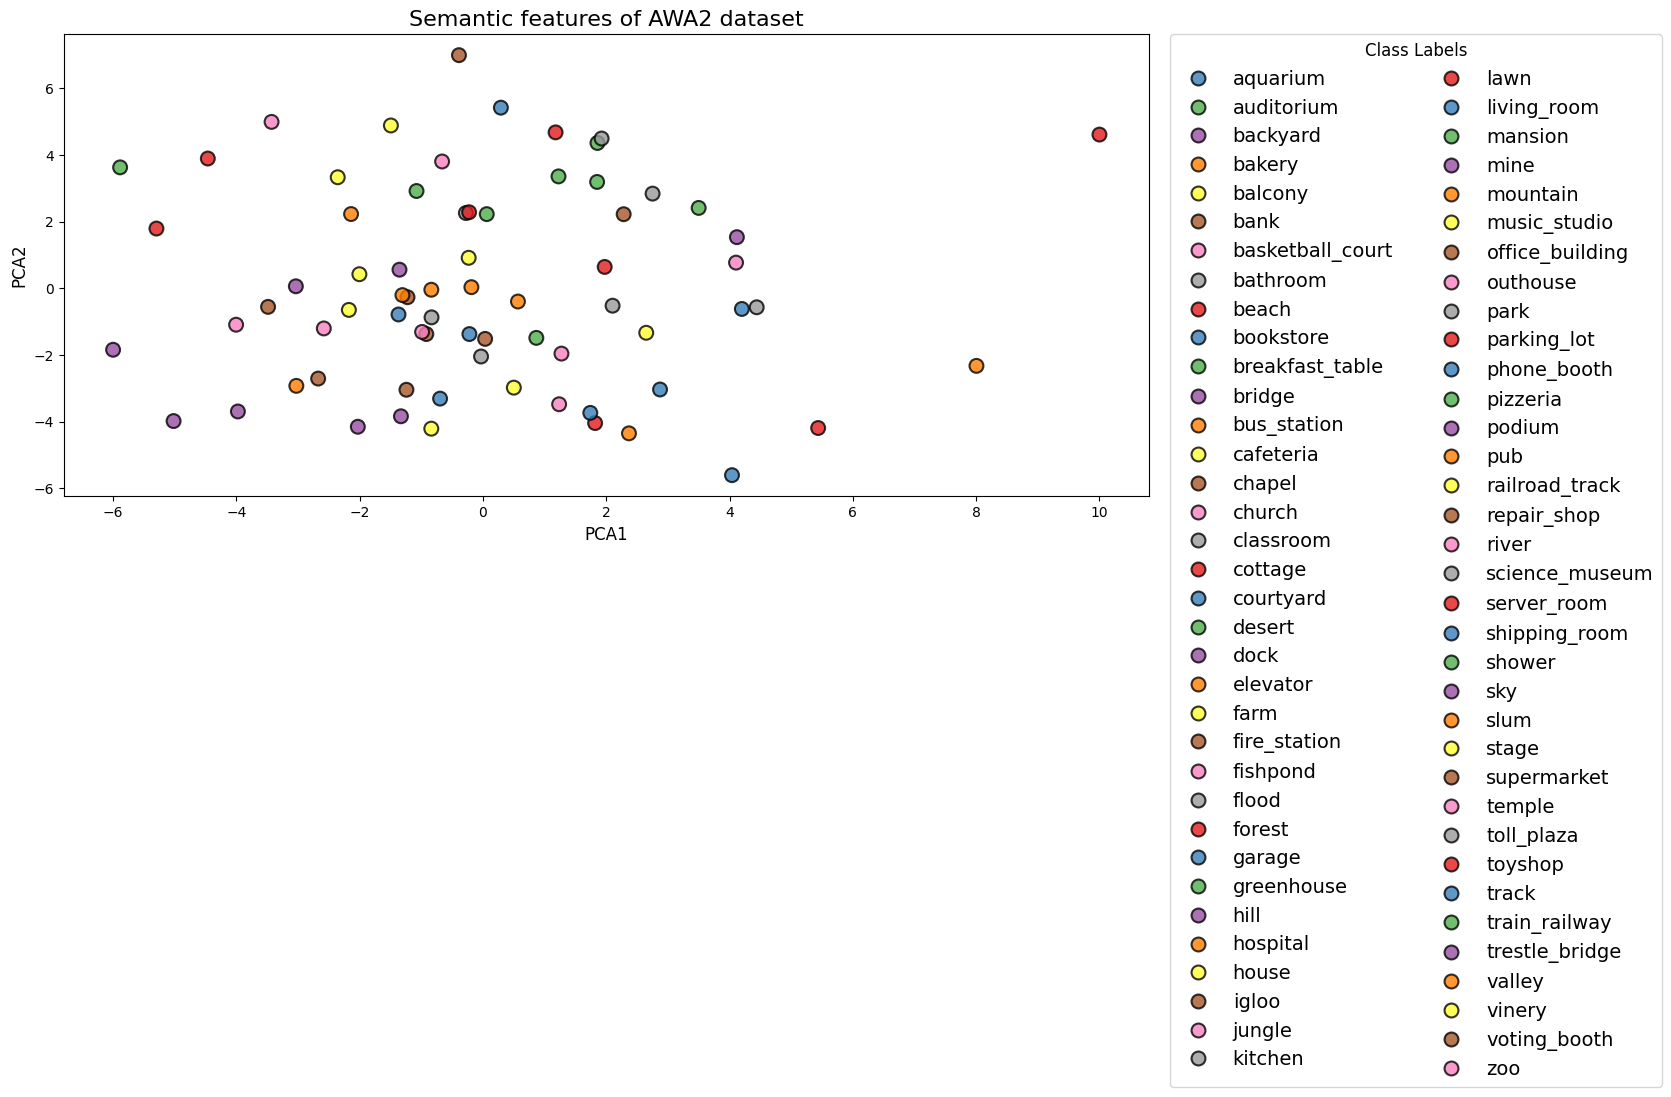

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Your sentences list
SUN_custom_sentences = ["airport", "aquarium", "auditorium", "backyard", "bakery", "balcony", 
                        "bank", "basketball_court", "bathroom", "beach", "bookstore", "breakfast_table", 
                        "bridge", "bus_station", "cafeteria", "chapel", "church", "classroom", 
                        "cottage", "courtyard", "desert", "dock", "elevator", "farm", "fire_station", 
                        "fishpond", "flood", "forest", "garage", "greenhouse", "hill", "hospital", 
                        "house", "igloo", "jungle", "kitchen", "lawn", "living_room", "mansion", "mine", 
                        "mountain", "music_studio", "office_building", "outhouse", "park", "parking_lot", 
                        "phone_booth", "pizzeria", "podium", "pub", "railroad_track", "repair_shop", "river", 
                        "science_museum", "server_room", "shipping_room", "shower", "sky", "slum", "stage", 
                        "supermarket", "temple", "toll_plaza", "toyshop", "track", "train_railway", 
                        "trestle_bridge", "valley", "vinery", "voting_booth", "zoo"]

# Assuming you have these functions defined
# embeddings_index = load_glove_embeddings(r"glove.6B\glove.6B.300d.txt")
# sentence_to_embedding(sentence, embeddings_index)

custom_sentences = SUN_custom_sentences

# Your embeddings code here (commented out for example)
# sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])

# For demonstration, creating dummy embeddings
np.random.seed(42)
sentence_embeddings = np.random.randn(len(custom_sentences), 300)

print(f"embeddings_index : {type(embeddings_index)} \n")
print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

df = pd.DataFrame(sentence_embeddings)
df['custom_sentences'] = custom_sentences
df.head()

X = df.drop(columns='custom_sentences')
y = df['custom_sentences']

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame with PCA results and labels
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

# ========== OPTION 1: Using edgecolor parameter ==========
plt.figure(figsize=(14, 10))

# Create scatter plot with circle outlines
scatter = sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='label', 
    palette='Set1', 
    s=100,  # Increased size for better visibility
    edgecolor='black',  # Black outline
    linewidth=1.5,  # Thickness of outline
    alpha=0.8  # Slight transparency
)

plt.title('Semantic features of SUN dataset', fontsize=16 ) # , fontweight='bold'
plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)

# Increase tick label font size
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Custom two-column legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles[1:], labels=labels[1:],
    title='Class Labels',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., ncol=2, #fontsize=9, title_fontsize=11
    fontsize=12,          # legend labels font
    title_fontsize=14     # legend title font
)

plt.tight_layout()

# Save image with 500 DPI
plt.savefig("sun_pca_plot.png", dpi=500, bbox_inches='tight')

plt.show()

# # ========== OPTION 2: Using matplotlib directly for more control ==========
# plt.figure(figsize=(14, 10))

# # Get unique labels and colors
# unique_labels = df_pca['label'].unique()
# palette = sns.color_palette('Set1', n_colors=len(unique_labels))

# # Create a dictionary mapping labels to colors
# label_to_color = {label: color for label, color in zip(unique_labels, palette)}

# # Plot each label separately to control edgecolor
# for label in unique_labels:
#     label_data = df_pca[df_pca['label'] == label]
#     color = label_to_color[label]
    
#     plt.scatter(
#         label_data['PC1'], 
#         label_data['PC2'],
#         color=color,
#         s=120,  # Marker size
#         edgecolor='black',  # Outline color
#         linewidth=2,  # Outline thickness
#         alpha=0.8,
#         label=label
#     )

# plt.title('SUN PCA Visualization with Thick Circle Outlines', fontsize=16, fontweight='bold')
# plt.xlabel('PCA1', fontsize=12)
# plt.ylabel('PCA2', fontsize=12)

# # Custom two-column legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles, labels=labels,
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, fontsize=9, title_fontsize=11
# )

# plt.tight_layout()
# plt.show()

# # ========== OPTION 3: Highlight specific points with different outline colors ==========
# plt.figure(figsize=(14, 10))

# # Create a list of outline colors (black for most, red for important ones)
# outline_colors = ['black'] * len(df_pca)

# # Example: Highlight specific categories with different outline colors
# important_categories = ['house', 'office_building', 'hospital', 'school']
# for i, label in enumerate(df_pca['label']):
#     if label in important_categories:
#         outline_colors[i] = 'red'  # Red outline for important categories

# # Plot with custom outline colors
# scatter = sns.scatterplot(
#     data=df_pca, 
#     x='PC1', 
#     y='PC2', 
#     hue='label', 
#     palette='Set1', 
#     s=100,
#     edgecolor=outline_colors,  # Custom outline colors
#     linewidth=2,  # Thicker outline for highlighted points
#     alpha=0.8
# )

# plt.title('SUN PCA Visualization with Highlighted Outlines', fontsize=16, fontweight='bold')
# plt.xlabel('PCA1', fontsize=12)
# plt.ylabel('PCA2', fontsize=12)

# # Add legend for outline colors
# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
#            markersize=10, markeredgecolor='black', markeredgewidth=2, label='Regular'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
#            markersize=10, markeredgecolor='red', markeredgewidth=2, label='Important')
# ]

# plt.legend(
#     handles=legend_elements,
#     title='Outline Legend',
#     bbox_to_anchor=(1.02, 0.85), loc='upper left',
#     borderaxespad=0., fontsize=10, title_fontsize=11
# )

# # Main legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 0.4), loc='upper left',
#     borderaxespad=0., ncol=2, fontsize=9, title_fontsize=11
# )

# plt.tight_layout()
# plt.show()

# # ========== OPTION 4: Annotated version with circle outlines ==========
# plt.figure(figsize=(16, 12))

# # Create scatter plot with outlines
# scatter = sns.scatterplot(
#     data=df_pca, 
#     x='PC1', 
#     y='PC2', 
#     hue='label', 
#     palette='tab20',  # Using tab20 for more distinct colors
#     s=120,
#     edgecolor='black',
#     linewidth=1.5,
#     alpha=0.9
# )

# plt.title('SUN PCA Visualization with Circle Outlines and Annotations', 
#           fontsize=18, fontweight='bold', pad=20)
# plt.xlabel('PCA1', fontsize=14)
# plt.ylabel('PCA2', fontsize=14)

# # Annotate some points (for example, first 10)
# for i in range(min(10, len(df_pca))):
#     plt.annotate(
#         df_pca.iloc[i]['label'],
#         (df_pca.iloc[i]['PC1'], df_pca.iloc[i]['PC2']),
#         xytext=(5, 5),
#         textcoords='offset points',
#         fontsize=9,
#         alpha=0.7,
#         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor='gray')
#     )

# # Custom legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, fontsize=8, title_fontsize=10
# )

# # Add grid for better readability
# plt.grid(True, alpha=0.3, linestyle='--')

# plt.tight_layout()
# plt.show()

# # ========== OPTION 5: Simple version (like your original but with outlines) ==========
# # This is closest to your original code, just adding the edgecolor parameter
# plt.figure(figsize=(10, 8))

# sns.scatterplot(
#     data=df_pca, 
#     x='PC1', 
#     y='PC2', 
#     hue='label', 
#     palette='Set1', 
#     s=80,
#     edgecolor='black',  # Added this for outline
#     linewidth=1  # Added this for outline thickness
# )

# plt.title('SUN PCA Visualization')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')

# # Custom two-column legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(
#     handles=handles[1:], labels=labels[1:],  # Skip auto title entry
#     title='Class Labels',
#     bbox_to_anchor=(1.02, 1), loc='upper left',
#     borderaxespad=0., ncol=2, fontsize=10, title_fontsize=12
# )

# plt.tight_layout()
# plt.show()

In [ ]:
import glob
import os

# Method 1: Using glob with wildcards
# Get all files in current directory
print("All files in current directory:")
for file in glob.glob(r"C:\ProjectWork\Basic_Python\Zero_shot_Learning\Notebook\CubUnseenDataset\unseen_50-20260126T131644Z-1-001\unseen_50\*"):
    print(file.split('\\')[-1], end=", ")